## Amortized mortgage additive payment simulation
It calculates amortized loan schedule with principals and interests. It also lists breakdown of the payment schedule when additive payment is paid.

In [1]:
%cd ..

d:\Workstation\mortgage_analysis


In [2]:
from src.loan_sim import LoanCalc

In [3]:
LOAN_AMT = 845796
LOAN_TERM = 360 #in month
LOAN_PMT = 7629 #total monthly payment
APR = 0.06125 #in percentage
PTAX = 0 #monthly property taxes
INS = 0 #homeowner's insurance
HOA = 0 #homeowner's association fees
PMI = 0 #private mortgage insurance
OTH = INS + HOA + PMI + 0

In [4]:
LOAN_AMT = 473360
LOAN_TERM = 360 #in month
LOAN_PMT = 4624 #total monthly payment
APR = 0.06375 #in percentage
PTAX = 0 #monthly property taxes
INS = 0 #homeowner's insurance
HOA = 0 #homeowner's association fees
PMI = 0 #private mortgage insurance
OTH = INS + HOA + PMI + 0

In [5]:
lc = LoanCalc(
    P=LOAN_AMT,
    r=APR,
    n=LOAN_TERM,
    O=OTH
)

#### Search optimal payment schedule
Search range is $10000 with a step of $100. The most efficient gain occurs early and gradually decreases after further addition to the monthly. Based on knee/elbow algorithm by Satoopaa et al, the optimal point of knee/elbow is found.

,Additive Down,Total Payment Schedule,Total Interest Paid,Percent Reduced
0,0.0,360.0,589774.199115,0.0
1,100.0,328.0,526572.726271,8.888889
2,200.0,302.0,477122.432512,16.111111
3,300.0,280.0,437090.996216,22.222222
4,400.0,262.0,403863.226651,27.222222
5,500.0,246.0,375739.816947,31.666667
6,600.0,233.0,351569.951025,35.277778
7,700.0,221.0,330531.696243,38.611111
8,800.0,210.0,312028.714168,41.666667
9,900.0,200.0,295606.899275,44.444444


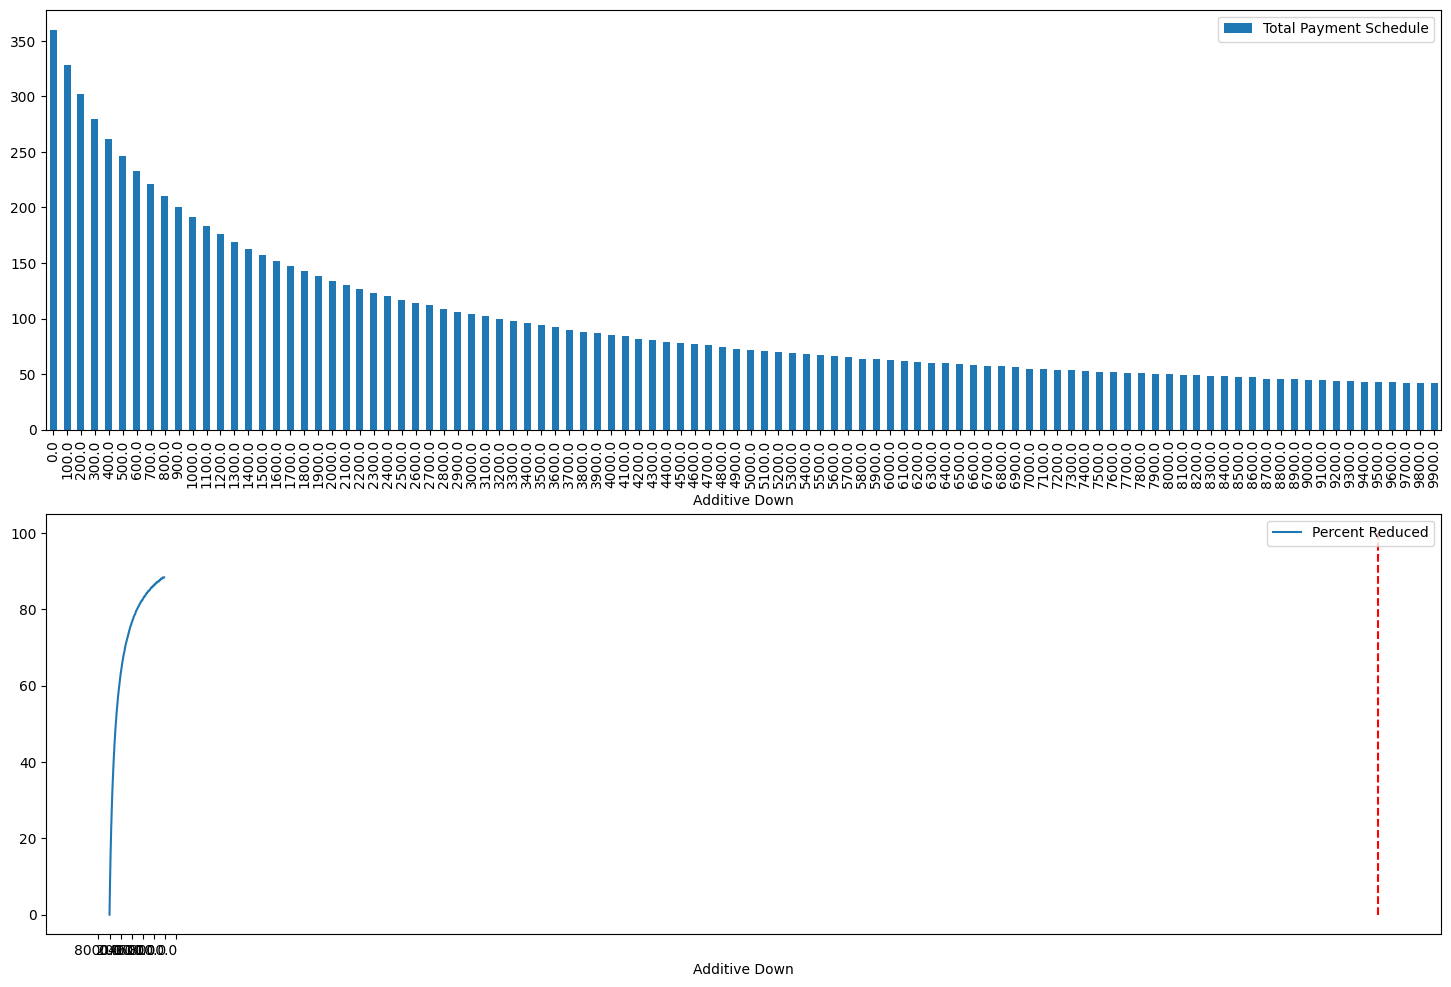

In [6]:
lc.find_optimal_schedule(search_range=range(0, 10000, 100), draw_plot=True, max_rows=20)

#### Amortization table without extra monthly

In [7]:
lc.generate_amortization_table(max_rows=20)

,Beginning Balance,Total Monthly,Interest,Principal,Other,Ending Balance,Total Principal,Total Interest,Percent Paid
1,473360.0,2953.15,2514.72,438.43,0.0,472921.57,438.43,2514.72,0.09
2,472921.57,2953.15,2512.4,440.75,0.0,472480.82,879.18,5027.12,0.19
3,472480.82,2953.15,2510.05,443.1,0.0,472037.72,1322.28,7537.18,0.28
4,472037.72,2953.15,2507.7,445.45,0.0,471592.27,1767.73,10044.88,0.37
5,471592.27,2953.15,2505.33,447.82,0.0,471144.46,2215.54,12550.21,0.47
6,471144.46,2953.15,2502.95,450.2,0.0,470694.26,2665.74,15053.16,0.56
7,470694.26,2953.15,2500.56,452.59,0.0,470241.67,3118.33,17553.73,0.66
8,470241.67,2953.15,2498.16,454.99,0.0,469786.68,3573.32,20051.89,0.75
9,469786.68,2953.15,2495.74,457.41,0.0,469329.27,4030.73,22547.63,0.85
10,469329.27,2953.15,2493.31,459.84,0.0,468869.43,4490.57,25040.94,0.95


#### Regenerate amortization table with optimal knee value

In [8]:
knee = lc.optimal_knee
knee

np.float64(2300.0)

In [9]:
lc.generate_amortization_table(additive=knee)[:10]

,Beginning Balance,Total Monthly,Interest,Principal,Other,Ending Balance,Total Principal,Total Interest,Percent Paid
1,473360.0,5253.15,2514.72,2738.43,0.0,470621.57,2738.43,2514.72,0.58
2,470621.57,5253.15,2500.18,2752.97,0.0,467868.6,5491.4,5014.9,1.16
3,467868.6,5253.15,2485.55,2767.6,0.0,465101.0,8259.0,7500.45,1.74
4,465101.0,5253.15,2470.85,2782.3,0.0,462318.7,11041.3,9971.3,2.33
5,462318.7,5253.15,2456.07,2797.08,0.0,459521.62,13838.38,12427.37,2.92
6,459521.62,5253.15,2441.21,2811.94,0.0,456709.68,16650.32,14868.58,3.52
7,456709.68,5253.15,2426.27,2826.88,0.0,453882.8,19477.2,17294.85,4.11
8,453882.8,5253.15,2411.25,2841.9,0.0,451040.9,22319.1,19706.1,4.72
9,451040.9,5253.15,2396.15,2857.0,0.0,448183.9,25176.1,22102.26,5.32
10,448183.9,5253.15,2380.98,2872.17,0.0,445311.73,28048.27,24483.23,5.93


In [16]:
# Assuming you've created a `loan` instance
# Apply a lump sum payment of $50,000 on the 12th month
df, _ = lc.generate_amortization_table_with_lumpsum(lump_sum=200000, month=108)

Monthly equity gain from lump sum: $1070.69
Total interest saving 1 years ahead: $12848.28 + $280.94 = $13129.22
Total interest saving 2 years ahead: $25696.56 + $1423.75 = $27120.31
Total interest saving 3 years ahead: $38544.85 + $3485.02 = $42029.87
Total interest saving 4 years ahead: $51393.13 + $6525.05 = $57918.18
Total interest saving 5 years ahead: $64241.41 + $10608.09 = $74849.5
Total interest saving 7.5 years ahead (Final): $96362.11 + $183982.04 = $280344.15


In [11]:
df

,Beginning Balance,Total Monthly,Interest,Principal,Other,Ending Balance,Total Principal,Total Interest,Percent Paid
1,473360.0,2953.15,2514.72,438.43,0.0,472921.57,438.43,2514.72,0.09
2,472921.57,2953.15,2512.4,440.75,0.0,472480.82,879.18,5027.12,0.19
3,472480.82,2953.15,2510.05,443.1,0.0,472037.72,1322.28,7537.18,0.28
4,472037.72,2953.15,2507.7,445.45,0.0,471592.27,1767.73,10044.88,0.37
5,471592.27,2953.15,2505.33,447.82,0.0,471144.46,2215.54,12550.21,0.47
6,471144.46,2953.15,2502.95,450.2,0.0,470694.26,2665.74,15053.16,0.56
7,470694.26,2953.15,2500.56,452.59,0.0,470241.67,3118.33,17553.73,0.66
8,470241.67,2953.15,2498.16,454.99,0.0,469786.68,3573.32,20051.89,0.75
9,469786.68,2953.15,2495.74,457.41,0.0,469329.27,4030.73,22547.63,0.85
10,469329.27,2953.15,2493.31,459.84,0.0,468869.43,4490.57,25040.94,0.95
